<a href="https://colab.research.google.com/github/TWecks/Shor-Quantum-Error-Correction/blob/main/01_bit_flip_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this notebook, we demonstrate how a bit flip error (From here onwards refered to as a X error, since its action is identical to an X gate acting erroneously on the circuit) can be corrected using quantum circuit built in Qiskit.

# Imports

In [ ]:
!pip install qiskit-aer
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 95.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=20cd983b8dbd804704c687ec3c6a972eca1233a644e16a8628e307370e5a346b
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
from qiskit import QuantumCircuit,transpile
from qiskit.visualization import plot_histogram
import qiskit_aer
from qiskit_aer import AerSimulator
from qiskit import ClassicalRegister, QuantumRegister
from qiskit.circuit import Parameter


import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [ ]:
# Prepare a perfect simulator
backend_sim_perfect = AerSimulator()

# Prepare a noisy simulator
from qiskit_aer.noise import NoiseModel,depolarizing_error,ReadoutError
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.02, 2), ['cx', 'cz'])
noise_model.add_all_qubit_quantum_error(depolarizing_error(4e-3, 1), ['id', 'z', 's', 'sdg', 't', 'tdg', 'x', 'rx', 'y', 'ry'])
noise_model.add_all_qubit_readout_error(ReadoutError([[0.98,0.02],[0.02,0.98]]))
backend_sim_noisy = AerSimulator(noise_model=noise_model)

# Correcting a Bit Flip Error

The method for identifying and correcting X errors is well understood, and centers on the idea of encoding a single logical qubit into multiple physical qubits:

$|0_L> = |000>$

$|1_L> = |111>$

If an X error occurs, the result will be a single physical qubit changing from a 0 to a 1 (or 1 to a 0), and we can use majority rule to determine what the true state of the logical qubit should be.

For instance, we would identify $|010>$ to be the $|000>$ state after encountering a bit flip on the central qubit, and we would then correct as needed.

The method for identifying and correcting X errors is well understood, and centers on the idea of encoding a single logical qubit into multiple physical qubits:

$|0_L> = |000>$

$|1_L> = |111>$

If an X error occurs, the result will be a single physical qubit changing from a 0 to a 1 (or 1 to a 0), and we can use majority rule to determine what the true state of the logical qubit should be.

For instance, we would identify $|010>$ to be the $|000>$ state after encountering a bit flip on the central qubit, and we would then correct as needed.

Impelmenting this is fairly straightforward. Taking $q_0,  q_1, $ and $q_2$ to be the already encoded logical qubit, we can build error correction like so: this is fairly straightforward. Taking $q_0,  q_1, $ and $q_2$ to be the already encoded logical qubit, we can build error correction like so:

In [ ]:
qr = QuantumRegister(5, 'q')
syndrome = ClassicalRegister(2, 'syn')  # for if_test comparisons
readout = ClassicalRegister(3, 'readout')    # for final data qubit measurements

x_corrected = QuantumCircuit(qr, syndrome, readout)


x_corrected.cx(0,3)
x_corrected.cx(1,3)
x_corrected.cx(1,4)
x_corrected.cx(2,4)

x_corrected.measure(3, syndrome[0])  # s[0]
x_corrected.measure(4, syndrome[1])  # s[1]


#IF classical bits are 10, execute x gate on q0
#IF classical bits are 11, execute x gate on q1
#IF classical bits are 01, execute x gate on q2
#IF classical bits are 00 do nothing.


with x_corrected.if_test((syndrome, 0b01)):
    x_corrected.x(0)

with x_corrected.if_test((syndrome, 0b11)):
    x_corrected.x(1)

with x_corrected.if_test((syndrome, 0b10)):
    x_corrected.x(2)


Drawing this circuit provides helpful visualization:

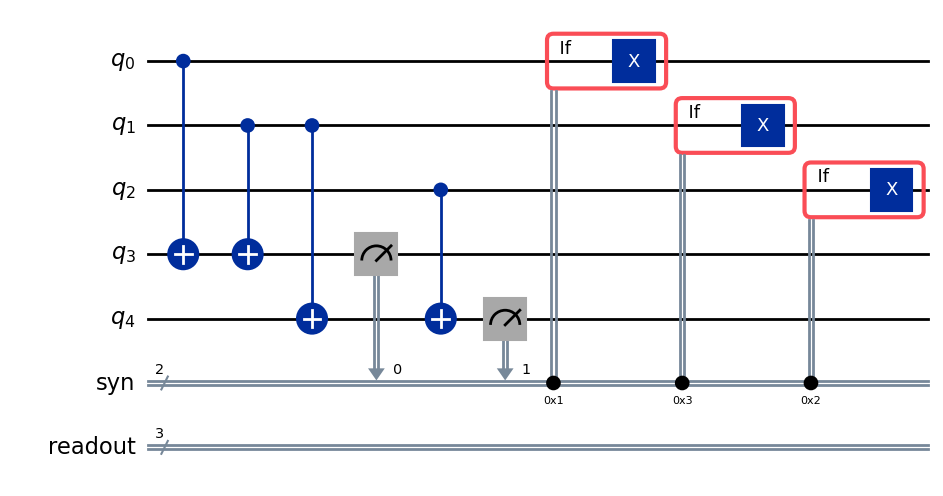

In [ ]:
x_corrected.draw('mpl')


This circuit implements an X gate in a location depending on the value of the two syndrome classical registers.

From here, we can build a simple circuit to induce an X error on the central qubit and graph the resulting bitstring post-error correction:

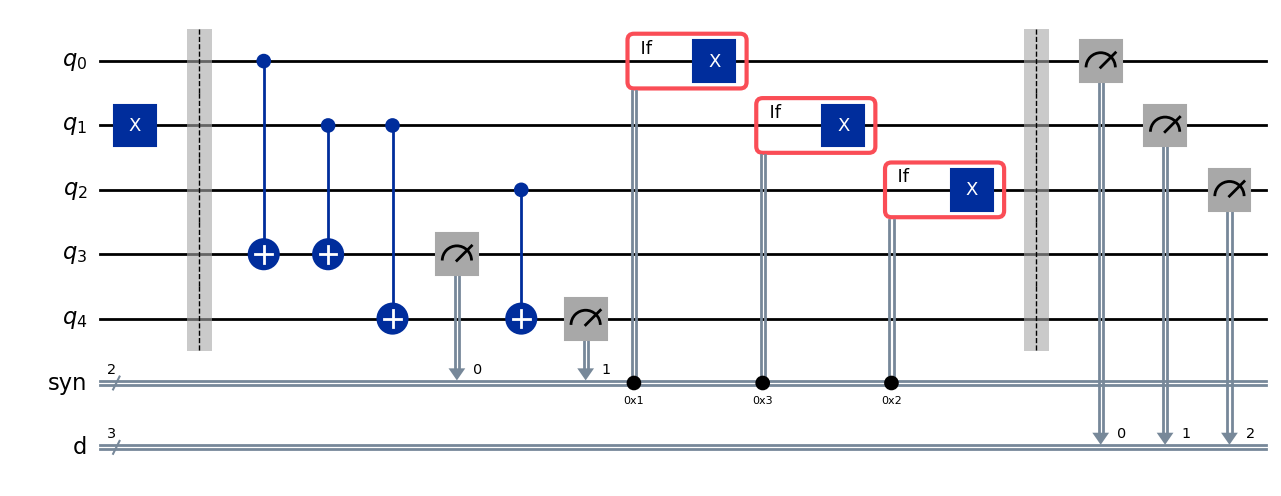

In [ ]:
x_error_test = QuantumCircuit(qr, syndrome, data_out)

# inject error on q1

x_error_test.x(1)


x_error_test.barrier()
x_error_test.compose(x_corrected, inplace=True)
x_error_test.barrier()

# Measure data qubits into data_out register
x_error_test.measure(0, data_out[0])
x_error_test.measure(1, data_out[1])
x_error_test.measure(2, data_out[2])

x_error_test.draw('mpl')

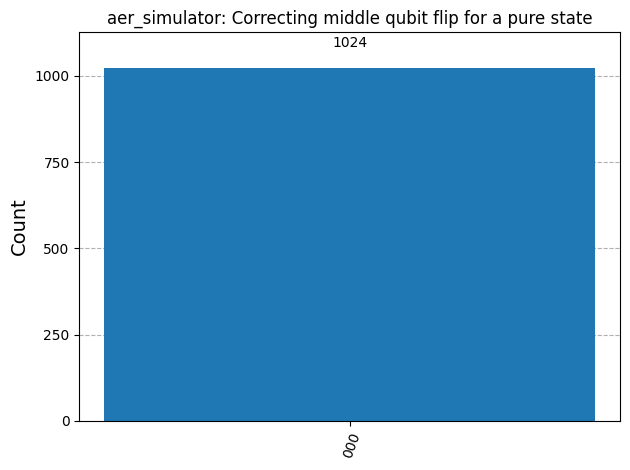

In [ ]:


backend = backend_sim_perfect
circ_comp = transpile(x_error_test, backend)
job = backend.run(circ_comp, shots=1024)
result = job.result()

# Qiskit separates registers with a space: "ddd ss"
# Split and take the first chunk (data_out register)
raw_counts = result.get_counts()
filtered_counts = {}
for bitstring, count in raw_counts.items():
    key = bitstring.split()[0]  # "ddd" — the data_out register
    filtered_counts[key] = filtered_counts.get(key, 0) + count

plot_histogram(filtered_counts, title=result.backend_name + ': Correcting middle qubit flip for a pure state')


As expected, this returns the same pure state as the input.


# Correcting Arbitrary X Rotations

To demonstrate a more comprehensive error correction, we will implement the incoming state as a GHZ state and act with an arbitrary X rotation, instead of simply an X gate.

The incoming state is now $\psi = \frac{1}{\sqrt{2}} ( |0_L> + |1_L>) = \frac{1}{\sqrt{2}} ( |000> + |111>)$


In [ ]:
theta = Parameter('θ')

arb_x_rot = QuantumCircuit(qr, syndrome, data_out)


arb_x_rot.h(0)
arb_x_rot.cx(0, 1)
arb_x_rot.cx(0, 2)
arb_x_rot.barrier()
arb_x_rot.rx(theta, 1)
arb_x_rot.barrier()
arb_x_rot.compose(x_corrected, inplace=True)
arb_x_rot.barrier()
arb_x_rot.measure(0, data_out[0])
arb_x_rot.measure(1, data_out[1])
arb_x_rot.measure(2, data_out[2])


arb_x_nocorrection = QuantumCircuit(qr, syndrome, data_out)

arb_x_nocorrection.h(0)
arb_x_nocorrection.cx(0, 1)
arb_x_nocorrection.cx(0, 2)
arb_x_nocorrection.barrier()
arb_x_nocorrection.rx(theta, 1)
arb_x_nocorrection.barrier()
arb_x_nocorrection.measure(0, data_out[0])
arb_x_nocorrection.measure(1, data_out[1])
arb_x_nocorrection.measure(2, data_out[2])



# UNCOMMENT TO DRAW:
# arb_x_rot.draw('mpl')



Below, we sweep over all values $ 0 \leq \theta \leq \pi$, and graph the resulting probabilities (really, computed probabilities from 1024 shots at each $\theta$) to demonstrate that for each theta value the lieklihood of measuring $|0_L>$ is the same as measuring $|1_L>$, which is the expected result for a GHZ state. This will be compared to a run with no error correction, to demonstrate the difference.

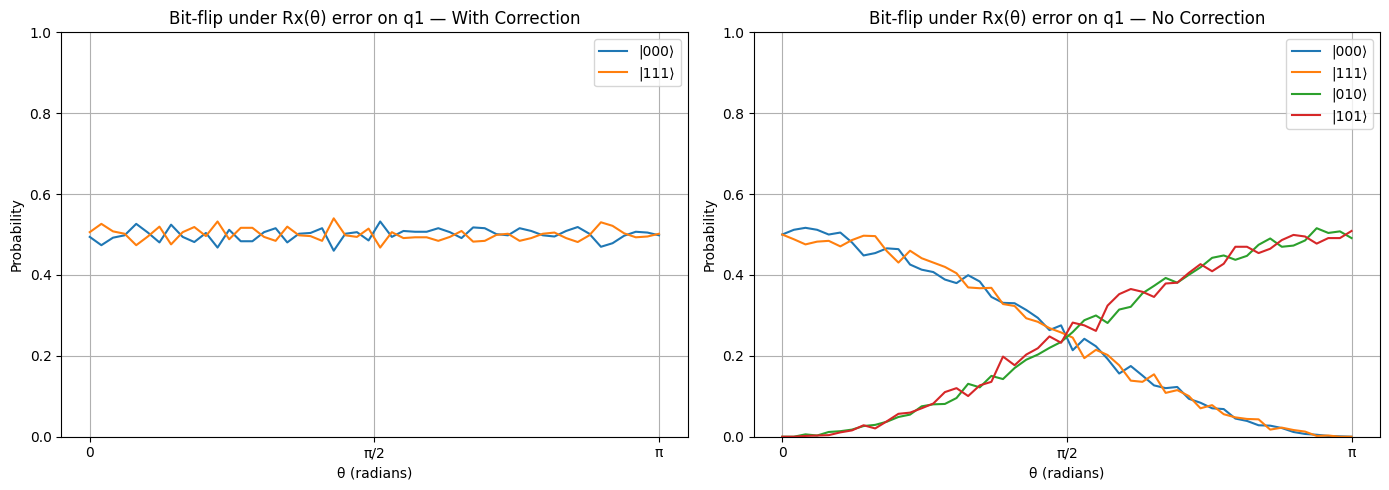

In [ ]:
# Sweep theta from 0 to pi
theta_values = np.linspace(0, np.pi, 50)

# Run jobs for both circuits
counts_corrected = []
counts_nocorrection = []

for t in theta_values:
    for circ, store in [(arb_x_rot, counts_corrected), (arb_x_nocorrection, counts_nocorrection)]:
        bound_circ = circ.assign_parameters({theta: t})
        circ_comp = transpile(bound_circ, backend_sim_perfect)
        job = backend_sim_perfect.run(circ_comp, shots=1024)
        result = job.result()
        raw = result.get_counts()
        filtered = {}
        for bitstring, count in raw.items():
            key = bitstring.split()[0]
            filtered[key] = filtered.get(key, 0) + count
        store.append(filtered)

# Extract probability of |000> across theta sweep for both circuits
def get_prob(counts_list, state):
    probs = []
    for counts in counts_list:
        total = sum(counts.values())
        probs.append(counts.get(state, 0) / total)
    return probs

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

all_states = ['000', '111', '001', '010', '100', '011', '101', '110']

for ax, counts_list, title in zip(axes,
                                   [counts_corrected, counts_nocorrection],
                                   ['With Correction', 'No Correction']):
    for s in all_states:
        probs = get_prob(counts_list, s)
        if max(probs) > 0.01:
            ax.plot(theta_values, probs, label=f'|{s}⟩')
    ax.set_xlabel('θ (radians)')
    ax.set_ylabel('Probability')
    ax.set_title(f'Bit-flip under Rx(θ) error on q1 — {title}')
    ax.set_xticks([0, np.pi/2, np.pi])
    ax.set_xticklabels(['0', 'π/2', 'π'])
    ax.legend()
    ax.set_ylim(0, 1)
    ax.grid(True)

plt.tight_layout()
plt.show()


The expected result, demonstrating the code is functioning as intended. So on our simulator, we see that we get each logical state with probability 1/2 and other states with probability 0, even after introducing a rotation by some arbitrary theta.